<a href="https://colab.research.google.com/github/ErnaZekovic/SQL_and_Excel_Analysis/blob/main/Optical_Spectroscopy_ML_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

# Simulate 600 optical spectroscopy measurements
np.random.seed(7)
wavelength_red = np.random.normal(50, 10, 600)
wavelength_green = np.random.choice([20, 70], size=600, p=[0.5, 0.5]) + np.random.normal(0, 5, 600)
wavelength_blue = wavelength_red * 0.5 + np.random.normal(20, 5, 600)

# Physics rule: 0 = Semiconductor Material, 1 = Optical Glass
material_type = np.where((wavelength_green > 50) & (wavelength_blue > 40), 1, 0)

# Pack everything into a clean English dataset
spectroscopy_data = pd.DataFrame({
    'Wavelength_Red_nm': wavelength_red,
    'Wavelength_Green_nm': wavelength_green,
    'Wavelength_Blue_nm': wavelength_blue,
    'Material_Class': material_type
})

print("Optical Spectroscopy Dataset successfully created!")
print(spectroscopy_data.head())

Optical Spectroscopy Dataset successfully created!
   Wavelength_Red_nm  Wavelength_Green_nm  Wavelength_Blue_nm  Material_Class
0          66.905257            25.832896           46.775495               0
1          45.340626            70.153048           44.377545               1
2          50.328202             8.240370           52.395574               0
3          54.075163            23.413183           52.095043               0
4          42.110770            11.970014           39.984372               0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Define features (X) and target label (y)
X = spectroscopy_data[['Wavelength_Red_nm', 'Wavelength_Green_nm', 'Wavelength_Blue_nm']]
y = spectroscopy_data['Material_Class']

# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Classifier
classifier_model = RandomForestClassifier(n_estimators=100, random_state=42)
classifier_model.fit(X_train, y_train)

# Generate predictions
predictions = classifier_model.predict(X_test)

# Display final model accuracy
model_accuracy = accuracy_score(y_test, predictions)
print(f"Optical Model Classification Accuracy: {model_accuracy * 100:.1f}%")

Optical Model Classification Accuracy: 100.0%


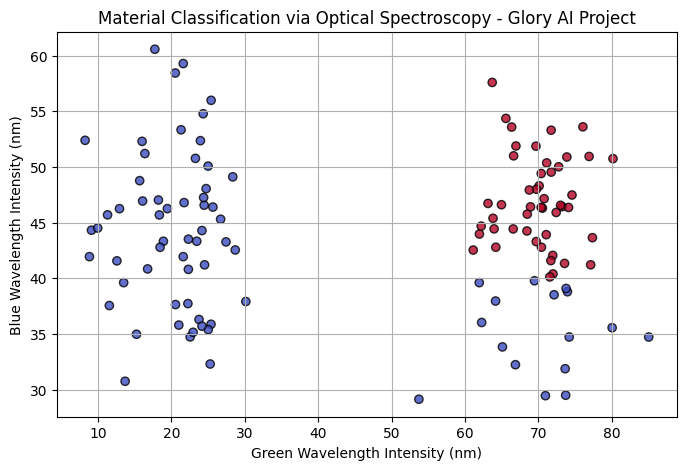

In [ ]:
import matplotlib.pyplot as plt

# Visualizing the material clusters based on green and blue wavelengths
plt.figure(figsize=(8, 5))
scatter = plt.scatter(X_test['Wavelength_Green_nm'], X_test['Wavelength_Blue_nm'],
                      c=y_test, cmap='coolwarm', alpha=0.8, edgecolors='k')

plt.xlabel('Green Wavelength Intensity (nm)')
plt.ylabel('Blue Wavelength Intensity (nm)')
plt.title('Material Classification via Optical Spectroscopy - Glory AI Project')
plt.grid(True)
plt.show()